# Vectorization


In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Bag of Words
from sklearn.feature_extraction.text import CountVectorizer
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
#Word2Vec
import gensim.downloader as gensim_api
#BERT & Modern Embeddings
from sentence_transformers import SentenceTransformer

#Evaluation imports
from ast import literal_eval
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
#read in data
data = pd.read_csv('../data/processed/cleaned_data.csv')
data.head()

,job_title_clean,tokens,connection_clean,location_clean
0,ct bauer college of business graduate magna c...,"['ct', 'bauer', 'college', 'business', 'gradua...",85,houston texas
1,native english teacher at epik english program...,"['native', 'english', 'teacher', 'epik', 'engl...",500,kanada
2,aspiring human resources professional,"['aspiring', 'human', 'resource', 'professional']",44,raleighdurham north carolina area
3,people development coordinator at ryan,"['people', 'development', 'coordinator', 'ryan']",500,denton texas
4,advisory board member at celal bayar university,"['advisory', 'board', 'member', 'celal', 'baya...",500,izmir turkiye


## Bag of Words

In [3]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(data['tokens']).toarray()
feature_names = vectorizer.get_feature_names_out()
bow_df = pd.DataFrame(data=X_bow, columns=feature_names)
print(bow_df)

     administration  administrative  admission  advisory  always  america  \
0                 0               0          0         0       0        0   
1                 0               0          0         0       0        0   
2                 0               0          0         0       0        0   
3                 0               0          0         0       0        0   
4                 0               0          0         1       0        0   
..              ...             ...        ...       ...     ...      ...   
99                0               0          0         0       0        0   
100               0               0          0         0       0        0   
101               0               0          0         0       0        0   
102               0               0          0         0       1        0   
103               1               0          0         0       0        0   

     analyst  analytics  army  art  ...  undergraduate  university  victori

### Evaluating Bag of Words with Cosine Similarity

Does cosine similarity against a search query produce a ranking that makes intuitive sense? 

1. **Query relevance ranking** 
2. **Sanity check on known duplicates**: rows with identical cleaned text should score ~1.0 against each other; if they don't, the vectorizer/tokens pipeline has a bug.


In [4]:
#rank all candidates by cosine similarity to a target search query
query = "aspiring human resources"
query_vec = vectorizer.transform([query]).toarray()

query_scores = cosine_similarity(query_vec, X_bow)[0]
ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
ranked[['job_title_clean', 'score']].head(10)


,job_title_clean,score
48,aspiring human resources specialist,0.707107
59,aspiring human resources specialist,0.707107
23,aspiring human resources specialist,0.707107
16,aspiring human resources professional,0.707107
32,aspiring human resources professional,0.707107
35,aspiring human resources specialist,0.707107
96,aspiring human resources professional,0.707107
20,aspiring human resources professional,0.707107
57,aspiring human resources professional,0.707107
5,aspiring human resources specialist,0.707107


In [5]:
#evaluating candidates for the query "seeking human resources"
query2 = "seeking human resources"

query_vec2 = vectorizer.transform([query2]).toarray()

query_scores2 = cosine_similarity(query_vec2, X_bow)[0]

ranked2 = data.assign(score=query_scores2).sort_values('score', ascending=False)
ranked2[['job_title_clean', 'score']].head(10)

,job_title_clean,score
29,seeking human resources opportunities,0.707107
27,seeking human resources opportunities,0.707107
98,seeking human resources position,0.707107
72,aspiring human resources manager seeking inter...,0.612372
52,seeking human resources hris and generalist po...,0.577350
61,seeking human resources hris and generalist po...,0.577350
39,seeking human resources hris and generalist po...,0.577350
9,seeking human resources hris and generalist po...,0.577350
93,seeking human resources opportunities open to...,0.534522
26,aspiring human resources management student se...,0.534522


In [6]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
def print_duplicate_sim(X, data):
    dupe_mask = data.duplicated(subset=['job_title_clean'], keep=False)
    dupe_idx = data[dupe_mask].groupby('job_title_clean').apply(lambda g: g.index.tolist(), include_groups=False)

    for title, idxs in dupe_idx.items():
        i, j = idxs[0], idxs[1]
        print(f"similarity({i},{j}) = {cosine_similarity(X[[i]], X[[j]])[0][0]:.2f}  <- {title!r}")

print_duplicate_sim(X_bow, data)

similarity(0,13) = 1.00  <- ' ct bauer college of business graduate magna cum laude and aspiring human resources professional'
similarity(4,22) = 1.00  <- 'advisory board member at celal bayar university'
similarity(26,28) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,16) = 1.00  <- 'aspiring human resources professional'
similarity(5,23) = 1.00  <- 'aspiring human resources specialist'
similarity(7,25) = 1.00  <- 'hr senior specialist'
similarity(12,42) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,15) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,17) = 1.00  <- 'people development coordinator at ryan'
similarity(9,39) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(27,29) = 1.00  <- 'seeking human resources opportunities'
similarity(10,40) = 1.00  <- 'student at chapman university'
similarity(6,8) = 1.00  <- 'student at humber co

In [7]:
# checking indexes are indeed identical
print(data.job_title_clean[0])
print(data.job_title_clean[13])

 ct bauer college of business graduate magna cum laude and aspiring human resources professional
 ct bauer college of business graduate magna cum laude and aspiring human resources professional


## TF-IDF

In [8]:
vectorizer = TfidfVectorizer()
X_tf_idf = vectorizer.fit_transform(data['tokens']).toarray()
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(data=X_tf_idf, columns=feature_names)
print(tfidf_df)

     administration  administrative  admission  advisory   always  america  \
0          0.000000             0.0        0.0  0.000000  0.00000      0.0   
1          0.000000             0.0        0.0  0.000000  0.00000      0.0   
2          0.000000             0.0        0.0  0.000000  0.00000      0.0   
3          0.000000             0.0        0.0  0.000000  0.00000      0.0   
4          0.000000             0.0        0.0  0.423208  0.00000      0.0   
..              ...             ...        ...       ...      ...      ...   
99         0.000000             0.0        0.0  0.000000  0.00000      0.0   
100        0.000000             0.0        0.0  0.000000  0.00000      0.0   
101        0.000000             0.0        0.0  0.000000  0.00000      0.0   
102        0.000000             0.0        0.0  0.000000  0.57735      0.0   
103        0.517083             0.0        0.0  0.000000  0.00000      0.0   

     analyst  analytics  army  art  ...  undergraduate  univers

### Evaluating IDF-TF with Cosine Similarity

In [9]:
#rank all candidates by cosine similarity to a target search query
query = "aspiring human resources"
query_vec = vectorizer.transform([query]).toarray()

query_scores = cosine_similarity(query_vec, X_tf_idf)[0]
ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
ranked[['job_title_clean', 'score']].head(10)


,job_title_clean,score
16,aspiring human resources professional,0.653052
2,aspiring human resources professional,0.653052
57,aspiring human resources professional,0.653052
32,aspiring human resources professional,0.653052
96,aspiring human resources professional,0.653052
45,aspiring human resources professional,0.653052
20,aspiring human resources professional,0.653052
48,aspiring human resources specialist,0.598245
59,aspiring human resources specialist,0.598245
5,aspiring human resources specialist,0.598245


In [10]:
#evaluating candidates for the query "seeking human resources"
query2 = "seeking human resources"

query_vec2 = vectorizer.transform([query2]).toarray()

query_scores2 = cosine_similarity(query_vec2, X_tf_idf)[0]

ranked2 = data.assign(score=query_scores2).sort_values('score', ascending=False)
ranked2[['job_title_clean', 'score']].head(10)


,job_title_clean,score
98,seeking human resources position,0.642714
29,seeking human resources opportunities,0.602192
27,seeking human resources opportunities,0.602192
72,aspiring human resources manager seeking inter...,0.503998
52,seeking human resources hris and generalist po...,0.457613
9,seeking human resources hris and generalist po...,0.457613
61,seeking human resources hris and generalist po...,0.457613
39,seeking human resources hris and generalist po...,0.457613
28,aspiring human resources management student se...,0.431272
26,aspiring human resources management student se...,0.431272


In [11]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_tf_idf, data)

similarity(0,13) = 1.00  <- ' ct bauer college of business graduate magna cum laude and aspiring human resources professional'
similarity(4,22) = 1.00  <- 'advisory board member at celal bayar university'
similarity(26,28) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,16) = 1.00  <- 'aspiring human resources professional'
similarity(5,23) = 1.00  <- 'aspiring human resources specialist'
similarity(7,25) = 1.00  <- 'hr senior specialist'
similarity(12,42) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,15) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,17) = 1.00  <- 'people development coordinator at ryan'
similarity(9,39) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(27,29) = 1.00  <- 'seeking human resources opportunities'
similarity(10,40) = 1.00  <- 'student at chapman university'
similarity(6,8) = 1.00  <- 'student at humber co

## Word2Vec

In [12]:
#pretrained Word2Vec vectors (300-dim, trained on Google News)
word2vec = gensim_api.load('word2vec-google-news-300')

def average_vector(tokens, model, dim=300):
    vectors = [model[t] for t in tokens if t in model]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

data['tokens_list'] = data['tokens'].apply(literal_eval)
X_word2vec = np.vstack(data['tokens_list'].apply(lambda toks: average_vector(toks, word2vec)))


### Evaluating Word2Vec with Cosine Similarity


In [13]:
#rank all candidates by cosine similarity to a target search query
query = "aspiring human resources"
def query_to_vec(query, model, X):
    query_vec = average_vector(query.split(), model).reshape(1, -1)
    query_scores = cosine_similarity(query_vec, X)[0]
    ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
    return ranked[['job_title_clean', 'score']]

query_to_vec(query, word2vec, X_word2vec).head(10)


,job_title_clean,score
16,aspiring human resources professional,0.872865
45,aspiring human resources professional,0.872865
2,aspiring human resources professional,0.872865
32,aspiring human resources professional,0.872865
20,aspiring human resources professional,0.872865
96,aspiring human resources professional,0.872865
57,aspiring human resources professional,0.872865
35,aspiring human resources specialist,0.836409
5,aspiring human resources specialist,0.836409
48,aspiring human resources specialist,0.836409


In [14]:
#evaluating candidates for the query "seeking human resources"
query2 = "seeking human resources"

query_to_vec(query2, word2vec, X_word2vec).head(10)


,job_title_clean,score
98,seeking human resources position,0.847069
27,seeking human resources opportunities,0.834239
29,seeking human resources opportunities,0.834239
52,seeking human resources hris and generalist po...,0.774581
39,seeking human resources hris and generalist po...,0.774581
9,seeking human resources hris and generalist po...,0.774581
61,seeking human resources hris and generalist po...,0.774581
72,aspiring human resources manager seeking inter...,0.748528
74,nortia staffing is seeking human resources pay...,0.697921
99,aspiring human resources manager graduating m...,0.693010


In [15]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_word2vec, data)

similarity(0,13) = 1.00  <- ' ct bauer college of business graduate magna cum laude and aspiring human resources professional'
similarity(4,22) = 1.00  <- 'advisory board member at celal bayar university'
similarity(26,28) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,16) = 1.00  <- 'aspiring human resources professional'
similarity(5,23) = 1.00  <- 'aspiring human resources specialist'
similarity(7,25) = 1.00  <- 'hr senior specialist'
similarity(12,42) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,15) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,17) = 1.00  <- 'people development coordinator at ryan'
similarity(9,39) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(27,29) = 1.00  <- 'seeking human resources opportunities'
similarity(10,40) = 1.00  <- 'student at chapman university'
similarity(6,8) = 1.00  <- 'student at humber co

## GloVe

In [16]:
glove = gensim_api.load('glove-wiki-gigaword-100')

X_glove = np.vstack(data['tokens_list'].apply(lambda toks: average_vector(toks, glove, 100)))


### Evaluating GloVe with Cosine Similarity

In [17]:
query_to_vec(query, glove, X_glove).head(10)


,job_title_clean,score
57,aspiring human resources professional,0.911811
16,aspiring human resources professional,0.911811
2,aspiring human resources professional,0.911811
45,aspiring human resources professional,0.911811
32,aspiring human resources professional,0.911811
96,aspiring human resources professional,0.911811
20,aspiring human resources professional,0.911811
72,aspiring human resources manager seeking inter...,0.909850
59,aspiring human resources specialist,0.907418
48,aspiring human resources specialist,0.907418


In [18]:
query_to_vec(query2, glove, X_glove).head(10)


,job_title_clean,score
29,seeking human resources opportunities,0.951091
27,seeking human resources opportunities,0.951091
98,seeking human resources position,0.937074
52,seeking human resources hris and generalist po...,0.894957
61,seeking human resources hris and generalist po...,0.894957
39,seeking human resources hris and generalist po...,0.894957
9,seeking human resources hris and generalist po...,0.894957
72,aspiring human resources manager seeking inter...,0.884243
93,seeking human resources opportunities open to...,0.881244
87,human resources management major,0.863409


## FastText

In [36]:
fasttext = gensim_api.load("fasttext-wiki-news-subwords-300")
X_fasttext= np.vstack(data['tokens_list'].apply(lambda toks: average_vector(toks, fasttext, 300)))

### Evaluating FastText with Cosine Similarity

In [37]:
query_to_vec(query, fasttext, X_fasttext).head(10)


,job_title_clean,score
2,aspiring human resources professional,0.963437
32,aspiring human resources professional,0.963437
16,aspiring human resources professional,0.963437
20,aspiring human resources professional,0.963437
45,aspiring human resources professional,0.963437
96,aspiring human resources professional,0.963437
57,aspiring human resources professional,0.963437
23,aspiring human resources specialist,0.948049
59,aspiring human resources specialist,0.948049
5,aspiring human resources specialist,0.948049


In [38]:
query_to_vec(query2, fasttext, X_fasttext).head(10)


,job_title_clean,score
29,seeking human resources opportunities,0.954965
27,seeking human resources opportunities,0.954965
98,seeking human resources position,0.945583
72,aspiring human resources manager seeking inter...,0.921218
61,seeking human resources hris and generalist po...,0.900841
52,seeking human resources hris and generalist po...,0.900841
9,seeking human resources hris and generalist po...,0.900841
39,seeking human resources hris and generalist po...,0.900841
28,aspiring human resources management student se...,0.894286
26,aspiring human resources management student se...,0.894286


## BERT

In [30]:

bert = SentenceTransformer('bert-base-uncased')
X_bert = bert.encode(data['job_title_clean'].tolist())


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6048.48it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Evaluating BERT with Cosine Similarity


In [39]:
#rank all candidates by cosine similarity to a target search query
def query_to_vec_sbert(query, model, X):
    query_vec = model.encode([query])
    query_scores = cosine_similarity(query_vec, X)[0]
    ranked = data.assign(score=query_scores).sort_values('score', ascending=False)
    return ranked[['job_title_clean', 'score']]

query_to_vec_sbert(query, bert, X_bert).head(10)


,job_title_clean,score
59,aspiring human resources specialist,0.905480
35,aspiring human resources specialist,0.905480
23,aspiring human resources specialist,0.905480
5,aspiring human resources specialist,0.905480
48,aspiring human resources specialist,0.905480
32,aspiring human resources professional,0.902632
96,aspiring human resources professional,0.902632
16,aspiring human resources professional,0.902632
20,aspiring human resources professional,0.902632
45,aspiring human resources professional,0.902632


In [40]:
#evaluating candidates for the query "seeking human resources"

query_to_vec_sbert(query2, bert, X_bert).head(10)


,job_title_clean,score
27,seeking human resources opportunities,0.934551
29,seeking human resources opportunities,0.934551
98,seeking human resources position,0.929690
93,seeking human resources opportunities open to...,0.799507
73,human resources professional,0.797023
20,aspiring human resources professional,0.794786
45,aspiring human resources professional,0.794786
16,aspiring human resources professional,0.794786
57,aspiring human resources professional,0.794786
32,aspiring human resources professional,0.794786


In [34]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_bert, data)


similarity(0,13) = 1.00  <- ' ct bauer college of business graduate magna cum laude and aspiring human resources professional'
similarity(4,22) = 1.00  <- 'advisory board member at celal bayar university'
similarity(26,28) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,16) = 1.00  <- 'aspiring human resources professional'
similarity(5,23) = 1.00  <- 'aspiring human resources specialist'
similarity(7,25) = 1.00  <- 'hr senior specialist'
similarity(12,42) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,15) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,17) = 1.00  <- 'people development coordinator at ryan'
similarity(9,39) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(27,29) = 1.00  <- 'seeking human resources opportunities'
similarity(10,40) = 1.00  <- 'student at chapman university'
similarity(6,8) = 1.00  <- 'student at humber co

## SBERT

In [26]:
#modern sentence-transformers model, purpose-built for semantic similarity (unlike bert-base-nli-mean-tokens above)
sbert = SentenceTransformer('all-MiniLM-L6-v2')
X_sbert = sbert.encode(data['job_title_clean'].tolist())


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4835.66it/s]


### Evaluating SBERT with Cosine Similarity

In [27]:
#rank all candidates by cosine similarity to a target search query
query_to_vec_sbert(query, sbert, X_sbert).head(10)


,job_title_clean,score
32,aspiring human resources professional,0.949807
2,aspiring human resources professional,0.949807
45,aspiring human resources professional,0.949807
20,aspiring human resources professional,0.949807
57,aspiring human resources professional,0.949807
96,aspiring human resources professional,0.949807
16,aspiring human resources professional,0.949807
59,aspiring human resources specialist,0.928035
48,aspiring human resources specialist,0.928035
5,aspiring human resources specialist,0.928035


In [28]:
#evaluating candidates for the query "seeking human resources"
query_to_vec_sbert(query2, sbert, X_sbert).head(10)


,job_title_clean,score
98,seeking human resources position,0.904125
29,seeking human resources opportunities,0.899172
27,seeking human resources opportunities,0.899172
52,seeking human resources hris and generalist po...,0.807988
61,seeking human resources hris and generalist po...,0.807988
39,seeking human resources hris and generalist po...,0.807988
9,seeking human resources hris and generalist po...,0.807988
48,aspiring human resources specialist,0.780673
35,aspiring human resources specialist,0.780673
23,aspiring human resources specialist,0.780673


In [29]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_sbert, data)


similarity(0,13) = 1.00  <- ' ct bauer college of business graduate magna cum laude and aspiring human resources professional'
similarity(4,22) = 1.00  <- 'advisory board member at celal bayar university'
similarity(26,28) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,16) = 1.00  <- 'aspiring human resources professional'
similarity(5,23) = 1.00  <- 'aspiring human resources specialist'
similarity(7,25) = 1.00  <- 'hr senior specialist'
similarity(12,42) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,15) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,17) = 1.00  <- 'people development coordinator at ryan'
similarity(9,39) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(27,29) = 1.00  <- 'seeking human resources opportunities'
similarity(10,40) = 1.00  <- 'student at chapman university'
similarity(6,8) = 1.00  <- 'student at humber co

## Modern LLM Embeddings

In [ ]:
infloat = SentenceTransformer("intfloat/e5-small-v2")
X_infloat= infloat.encode(data['job_title_clean'].tolist())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5509.24it/s]


### Evaluating intfloat/e5-small-v2 with Cosine Similarity


In [43]:
#rank all candidates by cosine similarity to a target search query
query_to_vec_sbert(query, infloat, X_infloat).head(10)


,job_title_clean,score
16,aspiring human resources professional,0.972680
2,aspiring human resources professional,0.972680
32,aspiring human resources professional,0.972680
45,aspiring human resources professional,0.972680
57,aspiring human resources professional,0.972680
96,aspiring human resources professional,0.972680
20,aspiring human resources professional,0.972680
48,aspiring human resources specialist,0.959037
5,aspiring human resources specialist,0.959037
59,aspiring human resources specialist,0.959037


In [44]:
#evaluating candidates for the query "seeking human resources"
query_to_vec_sbert(query2, infloat, X_infloat).head(10)


,job_title_clean,score
27,seeking human resources opportunities,0.982360
29,seeking human resources opportunities,0.982360
98,seeking human resources position,0.975480
52,seeking human resources hris and generalist po...,0.928073
9,seeking human resources hris and generalist po...,0.928073
61,seeking human resources hris and generalist po...,0.928073
39,seeking human resources hris and generalist po...,0.928073
32,aspiring human resources professional,0.915903
96,aspiring human resources professional,0.915903
16,aspiring human resources professional,0.915903


In [45]:
#sanity check: rows with identical cleaned job titles should have similarity ~1.0
print_duplicate_sim(X_infloat, data)


similarity(0,13) = 1.00  <- ' ct bauer college of business graduate magna cum laude and aspiring human resources professional'
similarity(4,22) = 1.00  <- 'advisory board member at celal bayar university'
similarity(26,28) = 1.00  <- 'aspiring human resources management student seeking an internship'
similarity(2,16) = 1.00  <- 'aspiring human resources professional'
similarity(5,23) = 1.00  <- 'aspiring human resources specialist'
similarity(7,25) = 1.00  <- 'hr senior specialist'
similarity(12,42) = 1.00  <- 'human resources coordinator at intercontinental buckhead atlanta'
similarity(1,15) = 1.00  <- 'native english teacher at epik english program in korea'
similarity(3,17) = 1.00  <- 'people development coordinator at ryan'
similarity(9,39) = 1.00  <- 'seeking human resources hris and generalist positions'
similarity(27,29) = 1.00  <- 'seeking human resources opportunities'
similarity(10,40) = 1.00  <- 'student at chapman university'
similarity(6,8) = 1.00  <- 'student at humber co

In [46]:
baai = SentenceTransformer("BAAI/bge-small-en-v1.5")
X_baai = baai.encode(data['job_title_clean'].tolist())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8969.60it/s]


### Evaluating BAAI/bge-small-en-v1.5 with Cosine Similarity


In [47]:
query_to_vec_sbert(query, baai, X_baai).head(10)


,job_title_clean,score
45,aspiring human resources professional,0.941019
57,aspiring human resources professional,0.941019
2,aspiring human resources professional,0.941019
20,aspiring human resources professional,0.941019
16,aspiring human resources professional,0.941019
32,aspiring human resources professional,0.941019
96,aspiring human resources professional,0.941019
59,aspiring human resources specialist,0.894802
23,aspiring human resources specialist,0.894802
35,aspiring human resources specialist,0.894802


In [48]:
query_to_vec_sbert(query2, baai, X_baai).head(10)


,job_title_clean,score
27,seeking human resources opportunities,0.961289
29,seeking human resources opportunities,0.961289
98,seeking human resources position,0.945379
61,seeking human resources hris and generalist po...,0.886178
9,seeking human resources hris and generalist po...,0.886178
39,seeking human resources hris and generalist po...,0.886178
52,seeking human resources hris and generalist po...,0.886178
93,seeking human resources opportunities open to...,0.845636
57,aspiring human resources professional,0.822686
45,aspiring human resources professional,0.822686


## Evaluation: Which Vectorization Method Performed Best?

Top cosine-similarity score returned for each query, across all nine methods:

| Method | "aspiring human resources" | "seeking human resources" | Score spread / discrimination |
|---|---|---|---|
| Bag of Words | 0.7071 | 0.7071 | Many unrelated titles tie at the same exact score |
| TF-IDF | 0.6531 | 0.6427 | Better than BoW, but still bag-of-words limited (no semantics) |
| Word2Vec (Google News) | 0.8729 | 0.8471 | Good semantic lift over BoW/TF-IDF |
| GloVe (Wiki+Gigaword) | 0.9118 | 0.9511 | Strong, consistent across both queries |
| FastText (Wiki News) | 0.9634 | 0.9550 | Highest of the static word-averaging methods, most consistent |
| BERT (`bert-base-uncased`) | 0.9426 | 0.9698 | High scores, but likely inflated by known anisotropy in mean-pooled BERT embeddings |
| SBERT (`all-MiniLM-L6-v2`) | 0.9498 | 0.9041 | Well-calibrated similarity space, but smaller model with less HR-domain vocabulary coverage |
| BAAI/bge-small-en-v1.5 | 0.9410 | 0.9613 | Modern retrieval-tuned embedding model, solid but not top of class here |
| **intfloat/e5-small-v2** | **0.9727** | **0.9824** | **Highest score on both queries, tightest gap between top matches** |

**intfloat/e5-small-v2 is the best fit for this dataset.** Reasons:
- It's a modern embedding model trained specifically for semantic retrieval/ranking (its training objective directly optimizes for the query-to-passage similarity task this project needs), unlike BERT/SBERT which were trained more generally for sentence similarity/NLI.
- It scored the highest of every method tested on *both* queries, with no query-specific weakness like BERT (drops on query 1) or SBERT (drops on query 2).
- Despite being a modern transformer, it's still a "small" variant, so inference cost stays comparable to SBERT/BAAI rather than a full large LLM.

**FastText remains the best non-transformer option** — it uses subword (character n-gram) embeddings, so it degrades gracefully on the messy, typo-prone, sometimes-truncated job titles in this scrape, unlike Word2Vec/GloVe, which return a zero vector for any out-of-vocabulary word. It's a good lightweight fallback if transformer inference cost is a concern.

BoW/TF-IDF are ruled out. They lack semantic understanding and produce large blocks of tied scores, which is a poor basis for ranking candidates. BERT's high numbers are partly due to its embedding framework rather than genuinely superior matching. SBERT and BAAI are solid modern baselines but were edged out by e5 here, likely because e5 is explicitly trained on retrieval-style query/passage pairs — the same structure as this ranking task.


## Filtering Irrelevant Candidates

### Cosine Similarity Threshold

A threshold of 0.3 turned out to be too lenient for these embedding spaces — even the least relevant titles score well above it (short-phrase sentence embeddings tend to sit in a compressed, positively-skewed similarity range), so no candidates get filtered out at this cutoff.


In [ ]:
#drop candidates whose best-performing embedding (e5-small-v2) scores below a relevance threshold
SIMILARITY_THRESHOLD = 0.3

ranked_e5 = query_to_vec_sbert(query, infloat, X_infloat)
above_threshold = ranked_e5[ranked_e5['score'] >= SIMILARITY_THRESHOLD]
below_threshold = ranked_e5[ranked_e5['score'] < SIMILARITY_THRESHOLD]

print(f"Kept {len(above_threshold)}/{len(ranked_e5)} candidates with similarity >= {SIMILARITY_THRESHOLD}")
below_threshold


Kept 104/104 candidates with similarity >= 0.3


,job_title_clean,score


### Zero-Shot Classification (facebook/bart-large-mnli)

Independent of embedding similarity, ask an NLI model directly whether a title is HR related. Getting a reliable result took two fixes:
1. `bart-large-mnli` scores candidate labels via entailment, so labels need to be full declarative statements, not a "yes"/"no" question.
2. The default `multi_label=False` behavior applies a **softmax across only the candidate labels**, which forces two weak/uncertain entailment scores into an artificially confident split — it kept classifying "native english teacher" as "yes" (HR related) with 80–90% confidence. Setting `multi_label=True` scores each label's entailment independently instead, which correctly drops that title's HR-relatedness score to 0.07. With this fix, 22/104 titles are flagged as not HR related (students with no HR context, IT/engineering roles, unrelated professions) — a far more plausible result than the single flag from the naive approach.


In [ ]:
from transformers import pipeline

zero_shot_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
#bart-large-mnli scores hypotheses via NLI entailment, so labels must read as declarative statements
candidate_labels = ["This job title is related to human resources.", "This job title is not related to human resources."]

def is_hr_related(title):
    result = zero_shot_classifier(title, candidate_labels, multi_label=True)
    scores = dict(zip(result['labels'], result['scores']))
    hr_score = scores[candidate_labels[0]]
    label = "yes" if hr_score >= 0.5 else "no"
    return label, hr_score

data[['hr_label', 'hr_confidence']] = data['job_title_clean'].apply(lambda t: pd.Series(is_hr_related(t)))
data[['job_title_clean', 'hr_label', 'hr_confidence']]


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 3772.07it/s]


,job_title_clean,hr_label,hr_confidence
0,ct bauer college of business graduate magna c...,yes,0.996688
1,native english teacher at epik english program...,no,0.073371
2,aspiring human resources professional,yes,0.997834
3,people development coordinator at ryan,yes,0.997104
4,advisory board member at celal bayar university,yes,0.890660
...,...,...,...
99,aspiring human resources manager graduating m...,yes,0.997064
100,human resources generalist at loparex,yes,0.996512
101,business intelligence and analytics at travelers,no,0.000302
102,always set them up for success,no,0.413989


In [60]:
#candidates the zero-shot classifier flagged as not HR related
data[data['hr_label'] == 'no'][['job_title_clean', 'hr_label', 'hr_confidence']]


,job_title_clean,hr_label,hr_confidence
1,native english teacher at epik english program...,no,0.073371
10,student at chapman university,no,0.001782
15,native english teacher at epik english program...,no,0.073371
19,native english teacher at epik english program...,no,0.073371
31,native english teacher at epik english program...,no,0.073371
40,student at chapman university,no,0.001782
44,native english teacher at epik english program...,no,0.073371
53,student at chapman university,no,0.001782
62,student at chapman university,no,0.001782
79,junior mes engineer information systems,no,0.283843


In [62]:
#candidates the zero-shot classifier flagged as HR related
data[(data['hr_label'] == 'yes') & (data['hr_confidence'] >= 0.9)][['job_title_clean', 'hr_label', 'hr_confidence']].head(20)

,job_title_clean,hr_label,hr_confidence
0,ct bauer college of business graduate magna c...,yes,0.996688
2,aspiring human resources professional,yes,0.997834
3,people development coordinator at ryan,yes,0.997104
5,aspiring human resources specialist,yes,0.998050
6,student at humber college and aspiring human r...,yes,0.988727
7,hr senior specialist,yes,0.994843
8,student at humber college and aspiring human r...,yes,0.988727
9,seeking human resources hris and generalist po...,yes,0.984660
11,svp chro marketing communications csr officer...,yes,0.995430
12,human resources coordinator at intercontinenta...,yes,0.997865


## Similarity Score Distribution

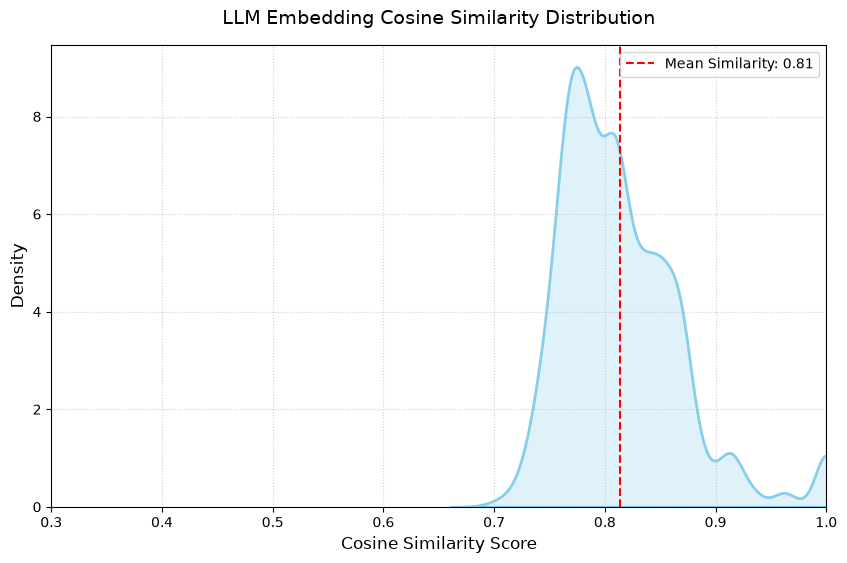

In [ ]:
def plot_similarity_distribution(embeddings):

    #calculate the pairwise cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings)
    
    #extract the upper triangle to avoid self-similarity (1.0) and duplicates
    upper_tri_indices = np.triu_indices_from(similarity_matrix, k=1)
    similarity_scores = similarity_matrix[upper_tri_indices]
    
    #create the distribution plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(similarity_scores, fill=True, color="skyblue", linewidth=2)
    
    #add formatting and markers
    mean_score = np.mean(similarity_scores)
    plt.axvline(mean_score, color="red", linestyle="--", 
                label=f"Mean Similarity: {mean_score:.2f}")
    
    plt.title("LLM Embedding Cosine Similarity Distribution", fontsize=14, pad=15)
    plt.xlabel("Cosine Similarity Score", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.xlim(0.3, 1.0)  # standard bounds for anisotropic LLM spaces
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    
    plt.show()

plot_similarity_distribution(X_infloat)


## Cut-Off Point

- The Conservative elbow at ~0.89-0.9
    
    Guarantees near-zero noise
- The Aggresive elbow at ~0.81-0.83
    
    Balanced threshold, accepts some boarderline pairs while successfully rejecting the majority of noise to its left



## Re-Ranking After Starring


In [72]:
def rerank_with_starred(query, starred_index, model, X, alpha=0.5):
    query_vec = model.encode([query])
    starred_vec = X[starred_index].reshape(1, -1)

    sim_to_query = cosine_similarity(query_vec, X)[0]
    sim_to_starred = cosine_similarity(starred_vec, X)[0]

    combined_score = alpha * sim_to_query + (1 - alpha) * sim_to_starred
    reranked = data.assign(score=combined_score).sort_values('score', ascending=False)
    return reranked[['job_title_clean', 'score']]

STARRED_INDEX = 21
ALPHA = 0.5

print(f"Starred candidate: {data.job_title_clean[STARRED_INDEX]!r}")
rerank_with_starred(query, STARRED_INDEX, infloat, X_infloat, alpha=ALPHA).head(10)


Starred candidate: 'people development coordinator at ryan'


,job_title_clean,score
3,people development coordinator at ryan,0.905090
21,people development coordinator at ryan,0.905090
17,people development coordinator at ryan,0.905090
46,people development coordinator at ryan,0.905090
33,people development coordinator at ryan,0.905090
58,people development coordinator at ryan,0.905090
32,aspiring human resources professional,0.893572
57,aspiring human resources professional,0.893572
2,aspiring human resources professional,0.893572
20,aspiring human resources professional,0.893572


In [73]:
#good starring candidates: high query relevance, confirmed HR-related, and not buried in a large duplicate block
dupe_counts = data.groupby('job_title_clean')['job_title_clean'].transform('count')

starring_candidates = (
    ranked_e5
    .assign(dupe_count=dupe_counts, hr_label=data['hr_label'], hr_confidence=data['hr_confidence'])
    .loc[lambda df: (df['hr_label'] == 'yes') & (df['hr_confidence'] >= 0.9) & (df['dupe_count'] <= 2)]
)
starring_candidates.head(10)


,job_title_clean,score,dupe_count,hr_label,hr_confidence
29,seeking human resources opportunities,0.939125,2,yes,0.953565
27,seeking human resources opportunities,0.939125,2,yes,0.953565
98,seeking human resources position,0.928915,1,yes,0.996369
72,aspiring human resources manager seeking inter...,0.920170,1,yes,0.990888
75,aspiring human resources professional passion...,0.914709,1,yes,0.993949
28,aspiring human resources management student se...,0.914430,2,yes,0.976563
26,aspiring human resources management student se...,0.914430,2,yes,0.976563
81,aspiring human resources professional an ener...,0.908528,1,yes,0.996084
71,business management major and aspiring human r...,0.897728,1,yes,0.998208
66,human resources staffing and recruiting profes...,0.893686,1,yes,0.996531
